
Traitement de 4 image(s) en batch...
Traitement de ./content/images_a_segmenter/pexels-diana-akhmedova-84744860-18980532.jpg
Traitement de ./content/images_a_segmenter/pexels-eugenia-remark-5767088-15239349.jpg
Traitement de ./content/images_a_segmenter/pexels-leo-gilmant-1144880343-32935722.jpg
Traitement de ./content/images_a_segmenter/pexels-pixabay-264172.jpg
Traitement en batch terminé.


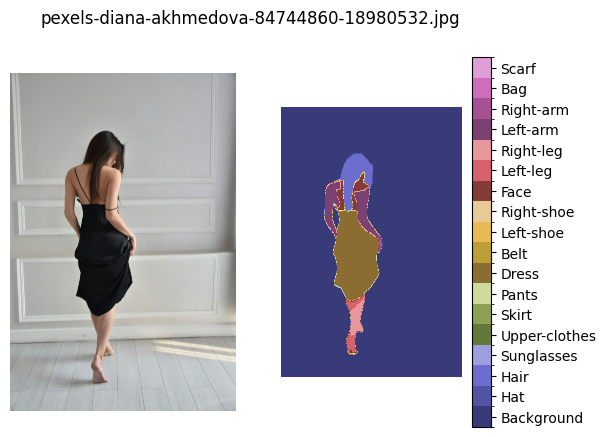

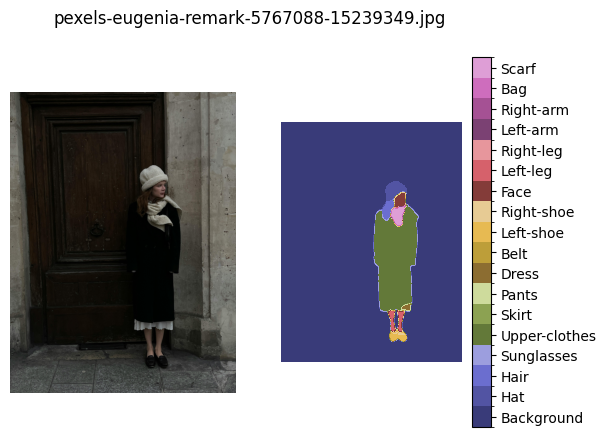

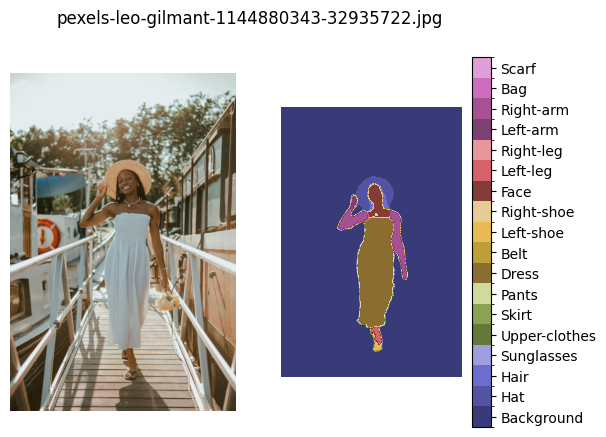

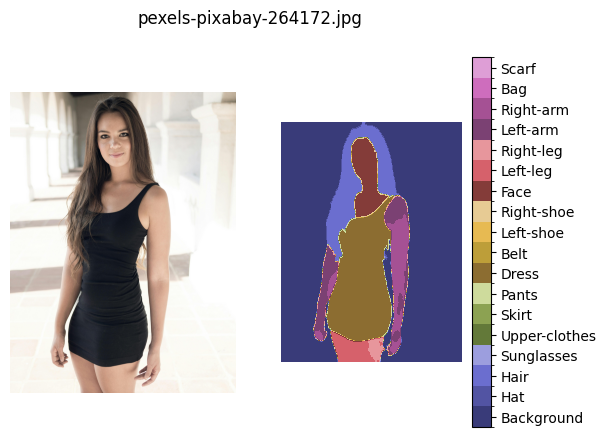

In [9]:
import os
from dotenv import load_dotenv
import func

load_dotenv()  # charge automatiquement le fichier .env

# variables globales
image_dir = "./content/images_a_segmenter"
output_dir = "./content/masks"
max_images = 50

# Lister les chemins des images à traiter
# Assurez-vous d'avoir des images dans le dossier 'image_dir'!
image_paths = [f"{image_dir}/{path}" for path in os.listdir(image_dir)]

# ignore les images déjà transformées
image_paths = [path for path in image_paths if os.path.exists(f"{output_dir}/{os.path.basename(path)}") == False]

# limite le nombre d'images
if max_images>0:
    image_paths = image_paths[:max_images]

# Appeler la fonction pour segmenter les images listées dans image_paths
if image_paths:
    print(f"\nTraitement de {len(image_paths)} image(s) en batch...")
    batch_seg_results = func.segment_images_batch(image_paths) 
    print("Traitement en batch terminé.")
else:
    batch_seg_results = []
    print("Aucune image à traiter en batch.")


# Exporte et Affiche les résultats du batch
if batch_seg_results:
    func.export_segmented_images_batch(output_dir, image_paths, batch_seg_results)
    func.display_segmented_images_batch(image_paths, batch_seg_results)
else:
    print("Aucun résultat de segmentation à afficher.")

In [10]:

import time

# variables globales
image_dir = "./perfs/images"
max_images = 6

# Lister les chemins des images à traiter
# Assurez-vous d'avoir des images dans le dossier 'image_dir'!
image_paths = [f"{image_dir}/{path}" for path in os.listdir(image_dir)]

# limite le nombre d'images
if max_images>0:
    image_paths = image_paths[:max_images]

# Segmente les images une à une et enregistre les performances
print(f"\nTraitement de {len(image_paths)} image(s) en batch...")
durations = [] # temps de traitement pour chaque image
scores = [] # score moyen pour chaque image
output = []
for filename in image_paths:
    print(f"Traitement de {filename}")
    infos={}
    func.segment_image(filename, infos)
    time.sleep(1)
    durations.append(infos['duration'])
    scores.append(infos['score'])
    print(filename, infos)
    output.append(f"{os.path.basename(filename)}, {infos}\n")
print("Traitement en batch terminé.")


print(f"performances pour {len(durations)} images")
print("scores", scores)
print("durations", durations)
print(f"durée moyenne", round(sum(durations) / len(durations), 2), "sec")
print(f"score moyen", sum(scores) / len(scores))



Traitement de 6 image(s) en batch...
Traitement de ./perfs/images/pexels-8pcarlos-morocho-2150734957-33716156.jpg
./perfs/images/pexels-8pcarlos-morocho-2150734957-33716156.jpg {'scores': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], 'score': 1.0, 'duration': 9.845213199999762}
Traitement de ./perfs/images/pexels-alex-paz-619370337-17381117.jpg
./perfs/images/pexels-alex-paz-619370337-17381117.jpg {'scores': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1], 'score': 1.0, 'duration': 8.585468199999923}
Traitement de ./perfs/images/pexels-anastasiya-gepp-654466-2065195.jpg
./perfs/images/pexels-anastasiya-gepp-654466-2065195.jpg {'scores': [1, 1, 1, 1, 1, 1, 1], 'score': 1.0, 'duration': 5.074367799999891}
Traitement de ./perfs/images/pexels-anna-nekrashevich-6203797.jpg
./perfs/images/pexels-anna-nekrashevich-6203797.jpg {'scores': [1, 1, 1, 1, 1, 1, 1, 1, 1], 'score': 1.0, 'duration': 6.050629899999876}
Traitement de ./perfs/images/pexels-athena-2043590.jpg
./perfs/images/pexels-athena-2043590.jpg {'scores': [


Traitement de l'image ./validation/test/image.png


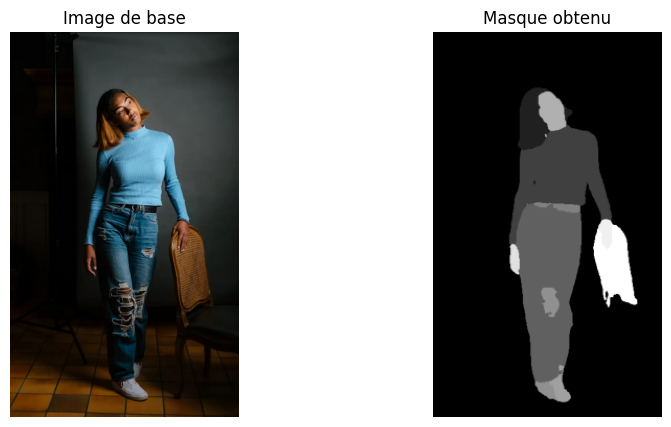

filename mask_2.png
mask_id 2
result_bbox (np.int64(131), np.int64(87), np.int64(216), np.int64(185))
expected_bbox (np.int64(130), np.int64(89), np.int64(217), np.int64(183))
filename mask_4.png
mask_id 4
result_bbox (np.int64(118), np.int64(145), np.int64(277), np.int64(331))
expected_bbox (np.int64(117), np.int64(145), np.int64(279), np.int64(332))
filename mask_6.png
mask_id 6
result_bbox (np.int64(127), np.int64(267), np.int64(230), np.int64(546))
expected_bbox (np.int64(134), np.int64(266), np.int64(230), np.int64(546))
filename mask_8.png
mask_id 8
result_bbox (np.int64(156), np.int64(266), np.int64(228), np.int64(282))
expected_bbox (np.int64(164), np.int64(268), np.int64(228), np.int64(282))


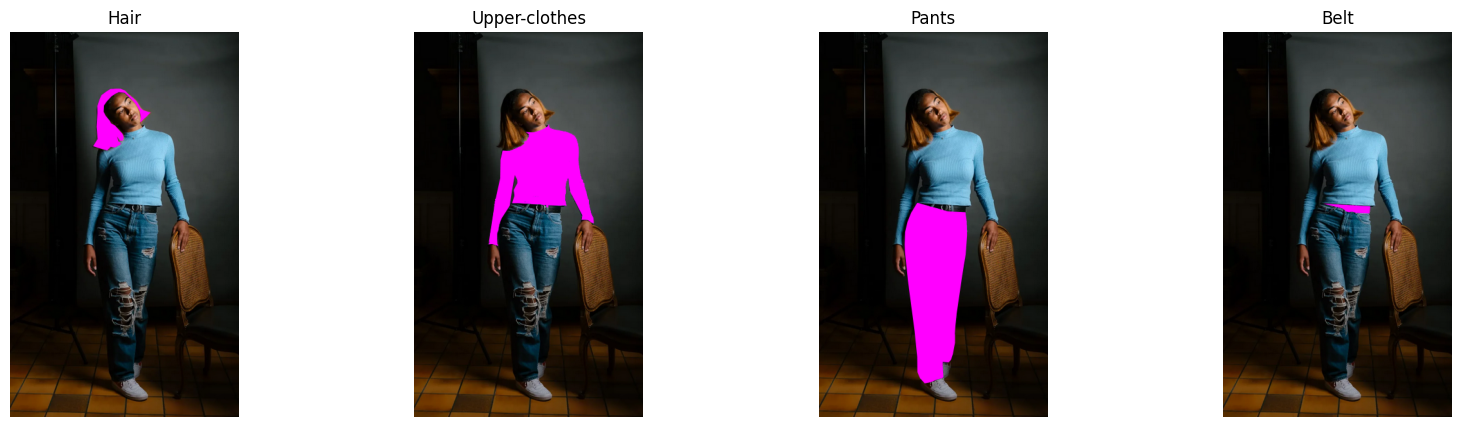

IoUs [np.float64(0.9380136182202395), np.float64(0.976232917409388), np.float64(0.9289355946311518), np.float64(0.7777777777777778)]
Resultat 0.91


In [19]:
import re
import matplotlib.image as mpimg
import matplotlib.pyplot as plt

load_dotenv()  # charge automatiquement le fichier .env

# variables globales
image_dir = "./validation/test"
output_file = f"{image_dir}/result.png"

# Lister les chemins des images à traiter
# Assurez-vous d'avoir des images dans le dossier 'image_dir'!
image_paths = [f"{image_dir}/{path}" for path in os.listdir(image_dir) if re.search(r"^image.(?:png|jpg|jpeg)$", os.path.basename(path))]
mask_paths = [f"{image_dir}/{path}" for path in os.listdir(image_dir) if re.search(r"^mask_[\d+].(?:png|jpg|jpeg)$", os.path.basename(path))]

# vérification des images en entrée
if len(image_paths) != 1:
    print("Aucune image à traiter ou plusieurs images présentes.")
    exit(1)

if len(mask_paths) == 0:
    print("Aucune image de masque pour traitement du résultat.")
    exit(1)

# Traitement
print(f"\nTraitement de l'image {image_paths[0]}")
# Appeler la fonction pour segmenter l'image en entrée
seg_results = func.segment_image(image_paths[0])
# Exporte l'image pour visualisation
func.export_segmented_image(output_file, seg_results)

fig, axes = plt.subplots(1, 2, figsize=(5 * 2, 5))

axes[0].set_title("Image de base")
axes[0].imshow(mpimg.imread(image_paths[0]))
axes[0].axis("off")

axes[1].set_title("Masque obtenu")
axes[1].imshow(mpimg.imread(output_file))
axes[1].axis("off")

plt.show()

# Test chaque masque de l'image
fig, axes = plt.subplots(1, len(mask_paths), figsize=(5 * len(mask_paths), 5))

i=0
IoUs = []
for path in mask_paths:
    # obtient l'id du masque recherché
    filename = os.path.basename(path)
    mask_id = int(filename[5:filename.rfind('.')]) # "mask_*.ext"
    print("filename", filename)
    print("mask_id", mask_id)
    # obtient le bounding-box du masque resultat
    result_bbox = func.get_mask_bbox(seg_results, mask_id)
    print("result_bbox",result_bbox)
    # si le masque n'existe pas on considère que c'est un raté
    if result_bbox is None:
        IoUs.append(0.0)
        print(f"mask {mask_id} introuvable")
        continue
    # obtient le bounding-box du masque attendu
    expected_bbox = func.get_color_mask_bbox(path)
    print("expected_bbox",expected_bbox)
    # calcule de l'IoU
    IoUs.append(func.cal_IoU_bbox(result_bbox, expected_bbox))
    axes[i].imshow(mpimg.imread(path))
    axes[i].set_title(next(k for k, v in func.CLASS_MAPPING.items() if v == mask_id))
    axes[i].axis("off")
    i=i+1

plt.axis("off")
plt.show()

print("IoUs",IoUs)
print("Resultat",round(sum(IoUs) / len(IoUs), 2))